# Values to compare
#### Target: overall_survival_months

#### Predictors:
#### age_at_diagnosis, cancer_type_detailed, chemotherapy, tumor_stage, tumor_size, type_of_breast_surgery death_from_cancer, 

#### Definitions
#### Invasive Ductal Carcinoma (IDC): IDC (approx. 80% of cases) starts in milk ducts and forms lumps
#### Invasive Lobular Carcinoma (ILC): ILC (10-15% of cases) starts in milk-producing lobules, often growing in single-file lines that make it harder to detect on mammograms. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# EDA

In [17]:
cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")
predictors = cancer_data[['age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer']]
cancer_data.head()

C:\Users\harri\AppData\Local\Temp\ipykernel_26632\1479979942.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


# Summary Statistics

In [18]:
#Qualitative predictors: cancer_type_detailed, 'type_of_breast_surgery', 'death_from_cancer'
predictors_description = predictors.describe()
print(predictors_description)

       age_at_diagnosis  chemotherapy  tumor_stage   tumor_size
count       1904.000000   1904.000000  1403.000000  1884.000000
mean          61.087054      0.207983     1.750535    26.238726
std           12.978711      0.405971     0.628999    15.160976
min           21.930000      0.000000     0.000000     1.000000
25%           51.375000      0.000000     1.000000    17.000000
50%           61.770000      0.000000     2.000000    23.000000
75%           70.592500      0.000000     2.000000    30.000000
max           96.290000      1.000000     4.000000   182.000000


In [10]:
missing_cancer_data = cancer_data.isna().sum()
missing_cancer_data[missing_cancer_data > 0]

type_of_breast_surgery             22
cancer_type_detailed               15
cellularity                        54
er_status_measured_by_ihc          30
neoplasm_histologic_grade          72
tumor_other_histologic_subtype     15
primary_tumor_laterality          106
mutation_count                     45
oncotree_code                      15
3-gene_classifier_subtype         204
tumor_size                         20
tumor_stage                       501
death_from_cancer                   1
dtype: int64

# Visualizations

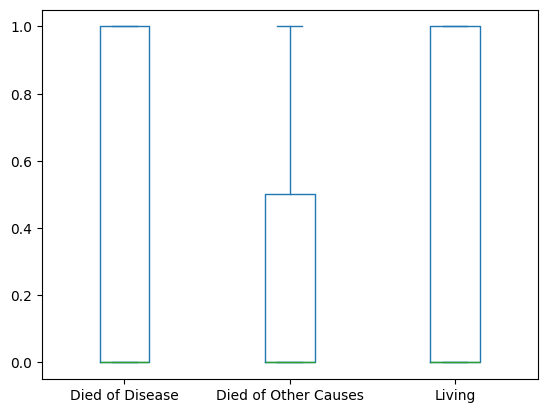

In [51]:
pd.crosstab(
    cancer_data["overall_survival_months"],
    cancer_data["death_from_cancer"],
    normalize="index"
).plot(kind="box", stacked=True)

plt.show()

# Correlations

In [45]:
['age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer']
survival_age_correlation = cancer_data['overall_survival_months'].corr(cancer_data['age_at_diagnosis'], method='spearman')
survival_chemotherapy_correlation = cancer_data['overall_survival_months'].corr(cancer_data['chemotherapy'], method='spearman')
survival_tumor_stage_correlation = cancer_data['overall_survival_months'].corr(cancer_data['tumor_stage'], method='spearman')
survival_tumor_size_correlation = cancer_data['overall_survival_months'].corr(cancer_data['tumor_size'], method='spearman')

print(survival_age_correlation)
print(survival_chemotherapy_correlation)
print(survival_tumor_stage_correlation)
print(survival_tumor_size_correlation)


-0.14130924864941208
-0.16695575109956204
-0.2804146615795238
-0.22806547183981116


# Section 2 BASELINE REGRESSION MODEL

## Baseline Formula

### Baseline: 
Survival = 𝐵_0+𝐵_1  (𝐴𝑔𝑒)+𝐵_2 (𝐶𝑎𝑛𝑐𝑒𝑟 𝑇𝑦𝑝𝑒)+𝐵_3 (𝐶ℎ𝑒𝑚𝑜)+𝐵_4 (𝑆𝑡𝑎𝑔𝑒)+B_5 (Size)+B_6 (𝑆𝑢𝑟𝑔𝑒𝑟𝑦)+∈

Predictors
- 𝑋_1=𝐴𝑔𝑒
- 𝑋_2=𝐶𝑎𝑛𝑐𝑒𝑟 𝑇𝑦𝑝𝑒
- 𝑋_3=𝐶ℎ𝑒𝑚𝑜 𝑇ℎ𝑒𝑟𝑎𝑝𝑦
- 𝑋_4=𝑆𝑡𝑎𝑔𝑒
- 𝑋_5=𝐶𝑎𝑛𝑐𝑒𝑟 𝑆𝑖𝑧𝑒
- 𝑋_6=𝑆𝑢𝑟𝑔𝑒𝑟𝑦 𝑇𝑦𝑝𝑒
- ∈ =𝐸𝑟𝑟𝑜𝑟



## Dummy Coding
- Column Name: type_of_breast_surgery
    - Reference Category: Breast conserving 
    - Mastectomy = 1
    - Breast conserving = 0
- Column Name: cancer_type

In [7]:
# Define index (rows)
index = [
    "IDC (Reference)",
    "Mixed DL",
    "Lobular",
    "Mucinous",
    "Breast",
    "Metaplastic"
]

# Create dummy-coded table
data = {
    "Mixed DL":   [0, 1, 0, 0, 0, 0],
    "Lobular":    [0, 0, 1, 0, 0, 0],
    "Mucinous":   [0, 0, 0, 1, 0, 0],
    "Breast":     [0, 0, 0, 0, 1, 0],
    "Metaplastic":[0, 0, 0, 0, 0, 1],
}

dummy_table = pd.DataFrame(data, index=index)

print(dummy_table)

                 Mixed DL  Lobular  Mucinous  Breast  Metaplastic
IDC (Reference)         0        0         0       0            0
Mixed DL                1        0         0       0            0
Lobular                 0        1         0       0            0
Mucinous                0        0         1       0            0
Breast                  0        0         0       1            0
Metaplastic             0        0         0       0            1


# Section 3: Variable Selection

### AIC, BIC, and CV with One Hot Encoding

In [2]:
import numpy as np

import statsmodels.api as sm    
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
target = "overall_survival_months"

models = {
    "Model 1": ["age_at_diagnosis", "tumor_stage", "tumor_size"],
    "Model 2": ["age_at_diagnosis", "tumor_stage", "tumor_size", "chemotherapy"],
    "Model 3": ["age_at_diagnosis", "tumor_stage", "tumor_size", "chemotherapy", "cancer_type_detailed"],
    "Model 4": ["age_at_diagnosis", "tumor_stage", "tumor_size", "chemotherapy", "cancer_type_detailed", "type_of_breast_surgery"],
}

/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_39059/2583207211.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [4]:
def evaluate_model(df, predictors, target, k=5, random_state=42):
    data = df[predictors + [target]].copy()

    # Ensure target is numeric
    data[target] = pd.to_numeric(data[target], errors="coerce")

    # Drop missing rows for this model
    data = data.dropna()

    y = data[target].astype(float)

    X = data[predictors].copy()

    # One-hot encode ALL object/category columns (including cancer_type_detailed)
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

    # Force everything to numeric float (this prevents the statsmodels error)
    X = X.astype(float)

    # ----- OLS for AIC/BIC -----
    X_ols = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X_ols).fit()

    aic, bic = model.aic, model.bic

    # ----- CV MSE -----
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    mse_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_ols = sm.add_constant(X_train, has_constant="add")
        X_test_ols = sm.add_constant(X_test, has_constant="add")

        fold_model = sm.OLS(y_train, X_train_ols).fit()
        y_pred = fold_model.predict(X_test_ols)

        mse_scores.append(mean_squared_error(y_test, y_pred))

    return {
        "n_obs": int(len(y)),
        "n_features_after_dummies": int(X.shape[1]),
        "AIC": float(aic),
        "BIC": float(bic),
        "CV_MSE_mean": float(np.mean(mse_scores)),
        "CV_MSE_std": float(np.std(mse_scores)),
        "CV_MSE_scores": mse_scores,
    }

### Results

In [6]:
results = []
for name, predictors in models.items():
    out = evaluate_model(df, predictors, target, k=5)
    results.append({
        "Model": name,
        "Predictors": ", ".join(predictors),
        "N": out["n_obs"],
        "Features(after dummies)": out["n_features_after_dummies"],
        "AIC": out["AIC"],
        "BIC": out["BIC"],
        "CV MSE(mean)": out["CV_MSE_mean"],
        "CV MSE(std)": out["CV_MSE_std"],
    })

results_df = pd.DataFrame(results)
results_df

/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_39059/3095901000.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
/var/folders/wz/29tjx61923s_d1p75gmh2qfw0000gn/T/ipykernel_39059/3095901000.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this wa

,Model,Predictors,N,Features(after dummies),AIC,BIC,CV MSE(mean),CV MSE(std)
0,Model 1,"age_at_diagnosis, tumor_stage, tumor_size",1400,3,16028.748347,16049.725257,5499.124312,241.004513
1,Model 2,"age_at_diagnosis, tumor_stage, tumor_size, che...",1400,4,15993.231751,16019.452889,5359.102166,319.176941
2,Model 3,"age_at_diagnosis, tumor_stage, tumor_size, che...",1392,9,15909.639179,15962.024147,5382.192148,454.900271
3,Model 4,"age_at_diagnosis, tumor_stage, tumor_size, che...",1379,10,15759.875822,15817.396075,5384.035544,211.104434


Interpretation: 
- Compared a sequence of models with increasing complexity. Each model added  variables to evaluate whether the added complexity improved performance.

- Model 1 included age at diagnosis, tumor stage, and tumor size. This serves the baseline clinical model and used 1,400 observations with three predictors.”

- Model 2, added chemotherapy. The sample size remained the same, and the number of features increased to four.

- Adding chemotherapy resulted in a noticeable improvement in performance. The cross-validated mean squared error decreased from about 5,499 to 5,359, which was the lowest error observed across all models.”

- Model 3, added cancer type. Because cancer type is categorical, it expanded into multiple dummy variables, increasing the total number of features from four to nine. At the same time, the sample size decreased slightly due to missing data.

- Although Model 3 improved AIC and BIC values, the cross-validated error increased compared to Model 2. This suggests that the additional complexity improved in-sample fit but did not improve performance on new data.

- Model 4 further added type of breast surgery, increasing the number of features to ten and reducing the sample size again. While AIC and BIC continued to decrease, cross-validated error remained essentially unchanged.


- Model 2 would be the best choice since it achieved the lowest cross-validated error while remaining parsimonious, and additional variables increased complexity without improving generalization.

# Group work split
# Chase: Section 6 and 7
# Harris: Section 4 and 5